In [7]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df_mortalidad_bgta = pd.read_csv('../datasets_limpios/mortalidad_bogota_limpio.csv', sep=';', index_col=None)
display(df_mortalidad_bgta)

,Año,Código,Localidad,Casos,Población,Tasa X 100.000 habitantes
0,2017,1,Usaquén,22.0,528924.0,4.2
1,2017,2,Chapinero,15.0,154506.0,9.7
2,2017,3,Santa Fe,9.0,102984.0,8.7
3,2017,4,San Cristóbal,24.0,382696.0,6.3
4,2017,5,Usme,22.0,358813.0,6.1
...,...,...,...,...,...,...
215,2025,16,Puente Aranda,34.0,251711.0,13.5
216,2025,17,La Candelaria,0.0,16801.0,0.0
217,2025,18,Rafael Uribe Uribe,22.0,379109.0,5.8
218,2025,19,Ciudad Bolívar,56.0,680206.0,8.2


# Análisis Descriptivo - Mortalidad en Bogotá (2017-2025)

En este notebook realizaremos un análisis descriptivo completo del dataset de mortalidad en Bogotá ya preprocesado. El objetivo es identificar patrones, tendencias y características relevantes de la mortalidad en las diferentes localidades a lo largo del tiempo.

## Información general del dataset
Primero revisemos la estructura básica del dataset y sus características principales.

In [25]:
print(f"Dimensiones del dataset: {df_mortalidad_bgta.shape}")
print(f"Total de registros: {df_mortalidad_bgta.shape[0]}")
print(f"Total de columnas: {df_mortalidad_bgta.shape[1]}")
print(f"\nRango temporal: {df_mortalidad_bgta['Año'].min()} - {df_mortalidad_bgta['Año'].max()}")
print(f"Número de localidades: {df_mortalidad_bgta['Localidad'].nunique()}")
print(f"\nTipos de datos de las Columnas del dataset:")
print(df_mortalidad_bgta.dtypes)

Dimensiones del dataset: (220, 6)
Total de registros: 220
Total de columnas: 6

Rango temporal: 2015 - 2025
Número de localidades: 20

Tipos de datos de las Columnas del dataset:
Año                            int64
Código                         int64
Localidad                        str
Casos                        float64
Población                    float64
Tasa X 100.000 habitantes    float64
dtype: object


## 1. Análisis Temporal de Mortalidad
Veamos cómo ha evolucionado la mortalidad en Bogotá a lo largo de los años. Analizaremos tanto el número total de casos como la tasa promedio de mortalidad por año.

In [24]:
# Agrupamos por año para obtener estadísticas temporales
casos_por_año = df_mortalidad_bgta.groupby('Año').agg({
    'Casos': 'sum',
    'Tasa X 100.000 habitantes': 'mean',
    'Población': 'sum'
}).round(2)

casos_por_año['Tasa Real'] = (casos_por_año['Casos'] / casos_por_año['Población'] * 100000).round(2)

# Renombramos la columna para dejar claro que es un promedio
casos_por_año.rename(columns={'Tasa X 100.000 habitantes': 'Tasa Promedio x 100.000 hab'}, inplace=True)

display(casos_por_año)

,Casos,Tasa Promedio x 100.000 hab,Población,Tasa Real
Año,,,,
2015,546.0,10.58,7273265.0,7.51
2016,585.0,10.92,7300918.0,8.01
2017,549.0,9.64,7337449.0,7.48
2018,525.0,11.00,7412566.0,7.08
2019,509.0,11.83,7592871.0,6.70
2020,392.0,8.38,7732161.0,5.07
2021,491.0,8.60,7823334.0,6.28
2022,581.0,10.38,7873316.0,7.38
2023,576.0,9.36,7907281.0,7.28


#### Visualización de la evolución temporal
Graficamos la evolución del número de casos y la tasa de mortalidad a lo largo de los años para identificar tendencias.

### 1.1 Evolución del Número de Casos
Visualizamos cómo ha cambiado el número total de casos de mortalidad cada año. Esta métrica nos permite ver la magnitud del problema en términos absolutos.

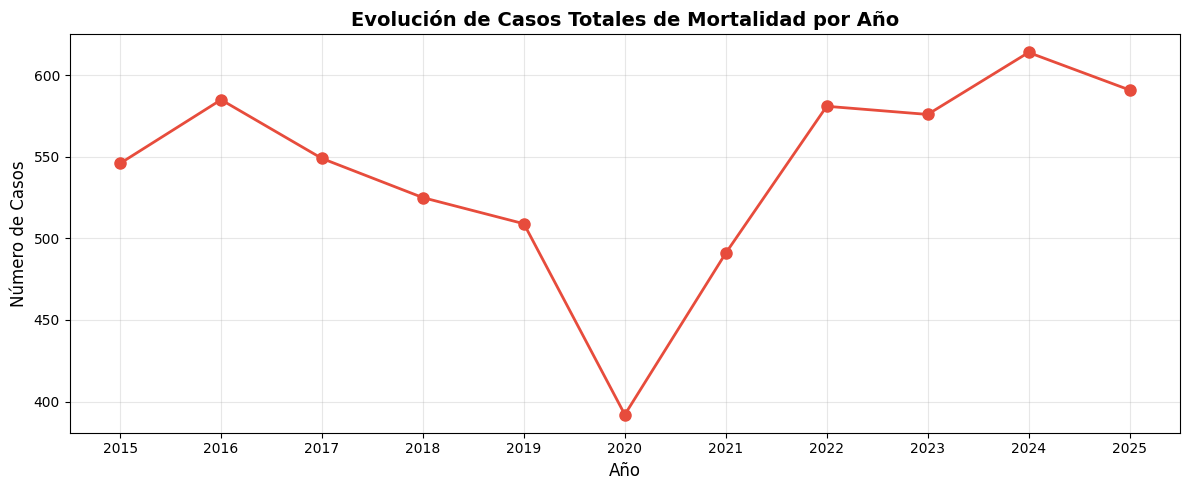

In [26]:
plt.figure(figsize=(12, 5))
plt.plot(casos_por_año.index, casos_por_año['Casos'], marker='o', linewidth=2, markersize=8, color='#e74c3c')
plt.title('Evolución de Casos Totales de Mortalidad por Año', fontsize=14, fontweight='bold')
plt.xlabel('Año', fontsize=12)
plt.ylabel('Número de Casos', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(casos_por_año.index)
plt.tight_layout()
plt.show()

### 1.2 Evolución de la Tasa de Mortalidad
Ahora visualizamos la tasa de mortalidad (Tasa Real) calculada correctamente para toda Bogotá. Esta métrica nos permite ver la tendencia normalizada por población, lo que da un mejor indicador del riesgo.

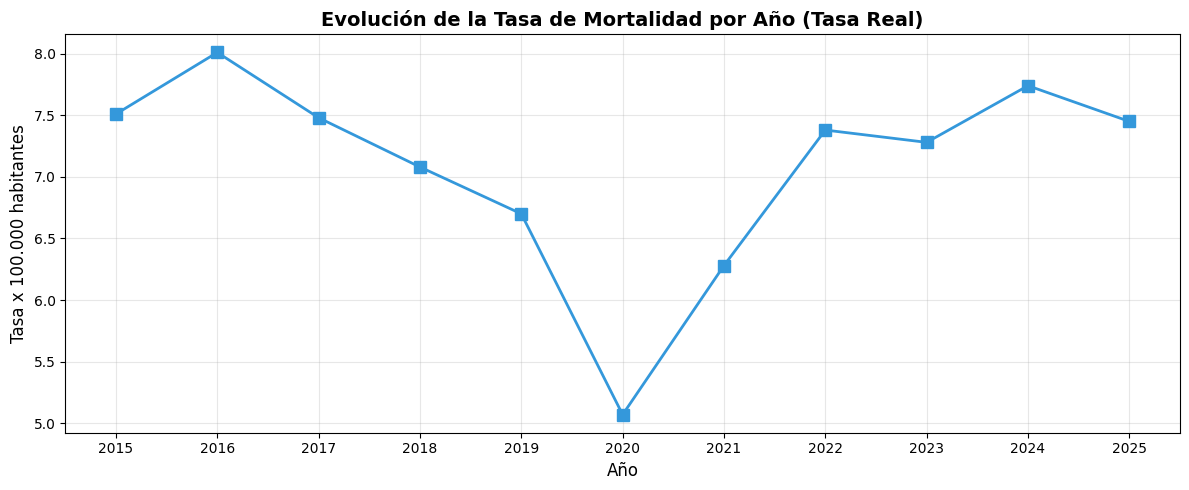

In [27]:
plt.figure(figsize=(12, 5))
plt.plot(casos_por_año.index, casos_por_año['Tasa Real'], marker='s', linewidth=2, markersize=8, color='#3498db')
plt.title('Evolución de la Tasa de Mortalidad por Año (Tasa Real)', fontsize=14, fontweight='bold')
plt.xlabel('Año', fontsize=12)
plt.ylabel('Tasa x 100.000 habitantes', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(casos_por_año.index)
plt.tight_layout()
plt.show()

## 2. Análisis por Localidad
Ahora analizaremos qué localidades tienen mayor y menor mortalidad, tanto en términos de casos totales como de tasa per cápita.

In [28]:
# Agrupamos por localidad
casos_por_localidad = df_mortalidad_bgta.groupby('Localidad').agg({
    'Casos': 'sum',
    'Tasa X 100.000 habitantes': 'mean',
    'Población': 'mean'
}).round(2)

# Ordenamos por número de casos
casos_por_localidad_sorted = casos_por_localidad.sort_values('Casos', ascending=False)

In [29]:
print("TOP 10 LOCALIDADES CON MÁS CASOS DE MORTALIDAD (Total acumulado 2017-2025)")
display(casos_por_localidad_sorted.head(10))

TOP 10 LOCALIDADES CON MÁS CASOS DE MORTALIDAD (Total acumulado 2017-2025)


,Casos,Tasa X 100.000 habitantes,Población
Localidad,,,
Kennedy,813.0,7.11,1043230.27
Engativá,564.0,6.33,809275.18
Suba,459.0,3.51,1195660.82
Ciudad Bolívar,430.0,6.11,639231.00
Fontibón,399.0,9.60,377857.45
Bosa,391.0,4.92,720108.73
Puente Aranda,384.0,14.13,247698.45
Usaquén,365.0,5.97,552768.73
Usme,273.0,6.52,379278.82


In [30]:

print("\n")
print("TOP 10 LOCALIDADES CON MENOS CASOS DE MORTALIDAD (Total acumulado 2017-2025)")
display(casos_por_localidad_sorted.tail(10))



TOP 10 LOCALIDADES CON MENOS CASOS DE MORTALIDAD (Total acumulado 2017-2025)


,Casos,Tasa X 100.000 habitantes,Población
Localidad,,,
San Cristóbal,240.0,5.56,393854.27
Rafael Uribe Uribe,233.0,5.65,373159.36
Los Mártires,225.0,25.65,80266.55
Teusaquillo,204.0,12.28,151536.27
Santa Fe,202.0,16.94,107703.27
Barrios Unidos,170.0,11.22,138374.82
Antonio Nariño,159.0,17.99,80304.55
Chapinero,158.0,8.95,161214.82
La Candelaria,18.0,9.49,17155.91


### 2.1 Análisis por Tasa de Mortalidad
Es importante también revisar la tasa de mortalidad promedio, ya que localidades con más población naturalmente tendrán más casos. La tasa normaliza esto.

In [36]:
# Ordenamos por tasa de mortalidad
casos_por_tasa = casos_por_localidad.sort_values('Tasa X 100.000 habitantes', ascending=False)

In [37]:
print("TOP 10 LOCALIDADES CON MAYOR TASA DE MORTALIDAD (Promedio 2017-2025)")
display(casos_por_tasa.head(10))

TOP 10 LOCALIDADES CON MAYOR TASA DE MORTALIDAD (Promedio 2017-2025)


,Casos,Tasa X 100.000 habitantes,Población
Localidad,,,
Los Mártires,225.0,25.65,80266.55
Sumapaz,7.0,18.63,3378.18
Antonio Nariño,159.0,17.99,80304.55
Santa Fe,202.0,16.94,107703.27
Puente Aranda,384.0,14.13,247698.45
Tunjuelito,265.0,13.78,175269.64
Teusaquillo,204.0,12.28,151536.27
Barrios Unidos,170.0,11.22,138374.82
Fontibón,399.0,9.60,377857.45


In [38]:
print("TOP 10 LOCALIDADES CON MENOR TASA DE MORTALIDAD (Promedio 2017-2025)")
display(casos_por_tasa.tail(10))

TOP 10 LOCALIDADES CON MENOR TASA DE MORTALIDAD (Promedio 2017-2025)


,Casos,Tasa X 100.000 habitantes,Población
Localidad,,,
Chapinero,158.0,8.95,161214.82
Kennedy,813.0,7.11,1043230.27
Usme,273.0,6.52,379278.82
Engativá,564.0,6.33,809275.18
Ciudad Bolívar,430.0,6.11,639231.00
Usaquén,365.0,5.97,552768.73
Rafael Uribe Uribe,233.0,5.65,373159.36
San Cristóbal,240.0,5.56,393854.27
Bosa,391.0,4.92,720108.73


### 2. Gráfico de Barras: Top 10 



Top 10 localidades con mas casos acumulados

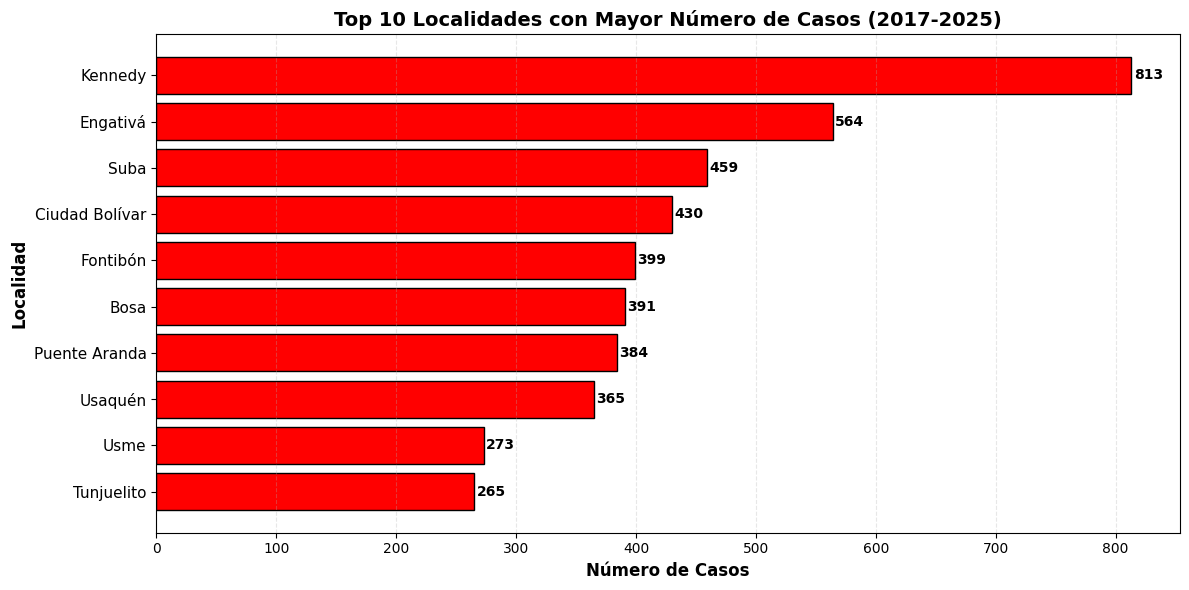

In [58]:
top10_casos = casos_por_localidad_sorted.head(10)

# Creamos la figura y los ejes usando matplotlib
fig, ax = plt.subplots(figsize=(12, 6))

# barh = bar horizontal, crea barras horizontales
ax.barh(range(len(top10_casos)), top10_casos['Casos'], color='red', edgecolor='black')

# set_yticks dice dónde van las etiquetas en el eje Y
ax.set_yticks(range(len(top10_casos)))

# set_yticklabels coloca los nombres de las localidades 
ax.set_yticklabels(top10_casos.index, fontsize=11)

# Configuramos las etiquetas y título
ax.set_xlabel('Número de Casos', fontsize=12, fontweight='bold')
ax.set_ylabel('Localidad', fontsize=12, fontweight='bold')
ax.set_title('Top 10 Localidades con Mayor Número de Casos (2017-2025)', fontsize=14, fontweight='bold')

# invert_yaxis() invierte el eje Y para que la localidad con más casos esté arriba
ax.invert_yaxis()

# Agregamos una cuadrícula para facilitar la lectura de valores
ax.grid(True, axis='x', alpha=0.3, linestyle='--')

# Agregamos los valores numéricos encima de cada barra
for i, v in enumerate(top10_casos['Casos']):
    ax.text(v + 2, i, str(int(v)), va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

Top 10 Localidades por Tasa de Mortalidad


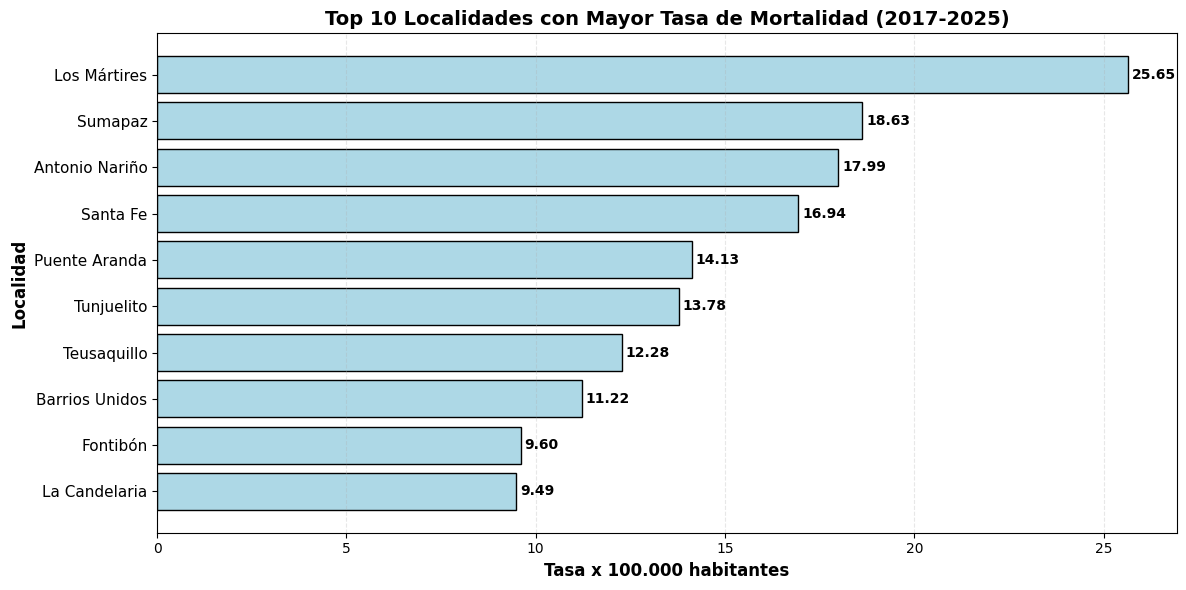

In [57]:
top10_tasa = casos_por_tasa.head(10)

# Creamos la figura y los ejes
fig, ax = plt.subplots(figsize=(12, 6))

# Creamos el gráfico de barras horizontales
ax.barh(range(len(top10_tasa)), top10_tasa['Tasa X 100.000 habitantes'], 
        color='lightblue', edgecolor='black')

# Configuramos los ejes Y (localidades)
ax.set_yticks(range(len(top10_tasa)))
ax.set_yticklabels(top10_tasa.index, fontsize=11)

# Configuramos las etiquetas y título
ax.set_xlabel('Tasa x 100.000 habitantes', fontsize=12, fontweight='bold')
ax.set_ylabel('Localidad', fontsize=12, fontweight='bold')
ax.set_title('Top 10 Localidades con Mayor Tasa de Mortalidad (2017-2025)', fontsize=14, fontweight='bold')

# Invertimos el eje para mejor visualización
ax.invert_yaxis()

# Agregamos cuadrícula
ax.grid(True, axis='x', alpha=0.3, linestyle='--')

# Agregamos los valores numéricos encima de cada barra
for i, v in enumerate(top10_tasa['Tasa X 100.000 habitantes']):
    ax.text(v + 0.1, i, f'{v:.2f}', va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

## 3. Análisis de Distribución
Revisemos cómo se distribuyen los casos y las tasas de mortalidad 

### 3.1 Distribución de Casos de Mortalidad
Analizamos la distribución de casos usando un boxplot (para ver la dispersión y valores atípicos) y un histograma (para ver la frecuencia de los datos).

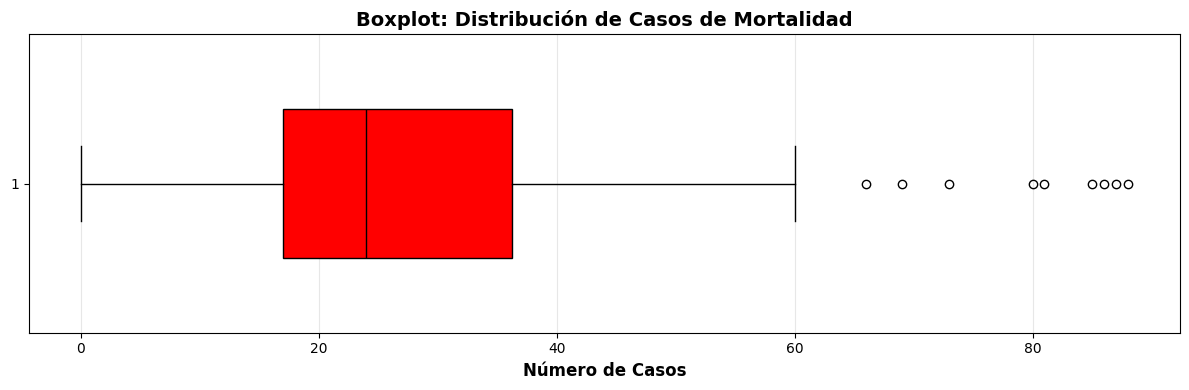

In [56]:
fig, ax = plt.subplots(figsize=(12, 4))

# boxplot() crea el diagrama y de forma horizontal
ax.boxplot(df_mortalidad_bgta['Casos'], vert=False, widths=0.5, 
           patch_artist=True,  # Permite personalizar colores
           boxprops=dict(facecolor='red',),  
           medianprops=dict(color='black',))  

# Configuramos etiquetas y título
ax.set_xlabel('Número de Casos', fontsize=12, fontweight='bold')
ax.set_title('Boxplot: Distribución de Casos de Mortalidad', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

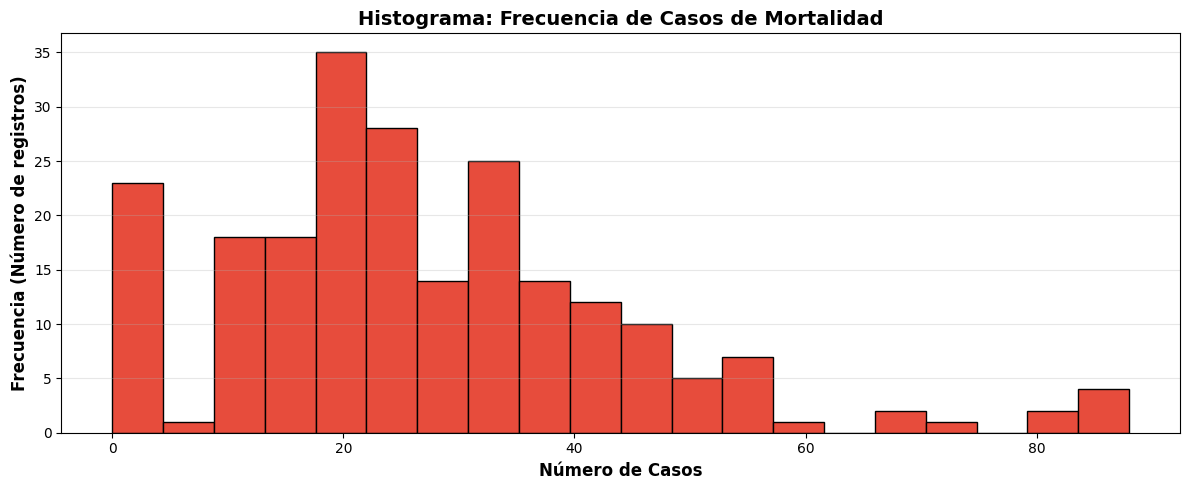

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

# hist() crea el histograma y bins=20 divide los datos en 20 intervalos
ax.hist(df_mortalidad_bgta['Casos'], bins=20, color='#e74c3c', edgecolor='black')

# Configuramos etiquetas y título
ax.set_xlabel('Número de Casos', fontsize=12, fontweight='bold')
ax.set_ylabel('Frecuencia (Número de registros)', fontsize=12, fontweight='bold')
ax.set_title('Histograma: Frecuencia de Casos de Mortalidad', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### 3.2 Distribución de Tasa de Mortalidad
Ahora analizamos la distribución de la tasa de mortalidad.

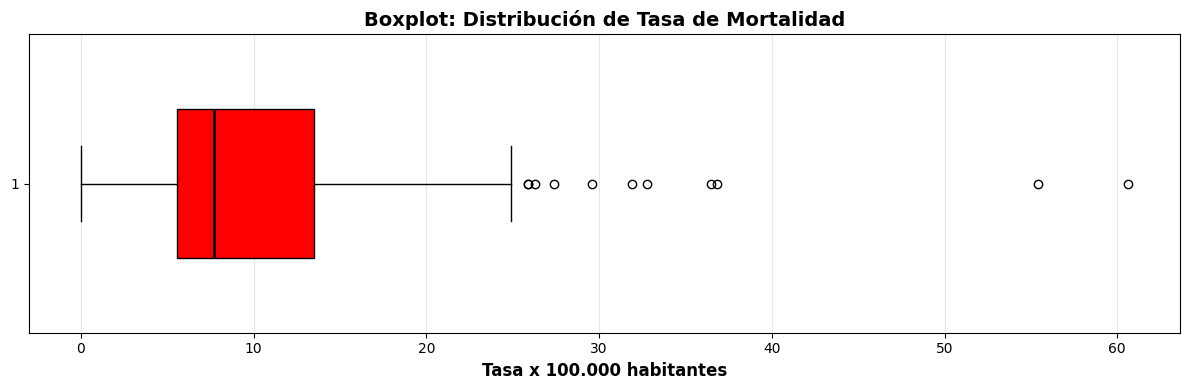

In [64]:
fig, ax = plt.subplots(figsize=(12, 4))

# Creamos el boxplot horizontal
ax.boxplot(df_mortalidad_bgta['Tasa X 100.000 habitantes'], vert=False, widths=0.5,
           patch_artist=True,
           boxprops=dict(facecolor='red' ),
           medianprops=dict(color='black', linewidth=2))

# Configuramos etiquetas y título
ax.set_xlabel('Tasa x 100.000 habitantes', fontsize=12, fontweight='bold')
ax.set_title('Boxplot: Distribución de Tasa de Mortalidad', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

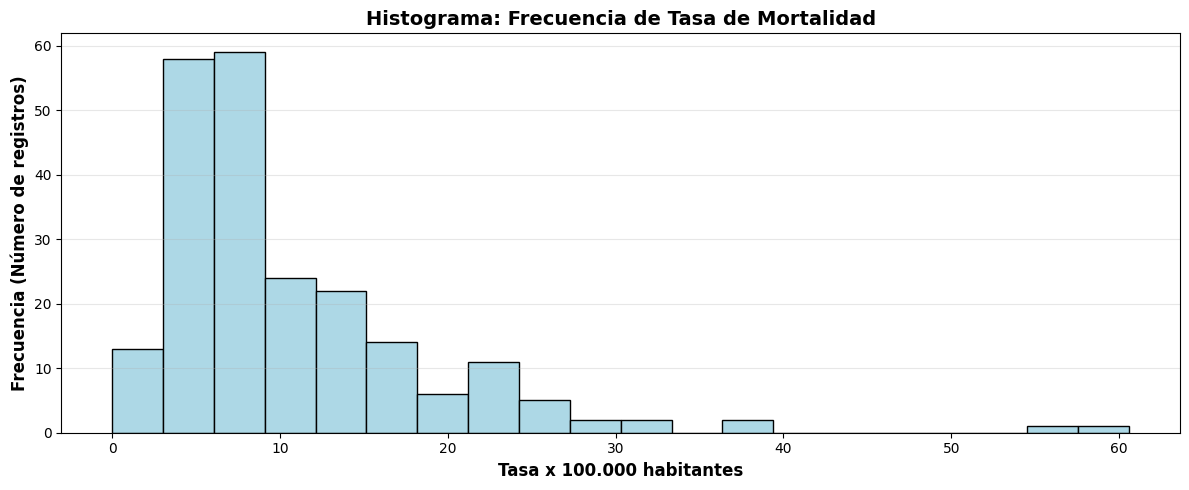

In [65]:
fig, ax = plt.subplots(figsize=(12, 5))

# Creamos el histograma con 20 intervalos
ax.hist(df_mortalidad_bgta['Tasa X 100.000 habitantes'], bins=20, color='lightblue', edgecolor='black')

# Configuramos etiquetas y título
ax.set_xlabel('Tasa x 100.000 habitantes', fontsize=12, fontweight='bold')
ax.set_ylabel('Frecuencia (Número de registros)', fontsize=12, fontweight='bold')
ax.set_title('Histograma: Frecuencia de Tasa de Mortalidad', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 4. Relación Población-Mortalidad
Analicemos si existe una correlación entre el tamaño de la población y el número de casos, y cómo varía la tasa según el tamaño poblacional.

En la matriz de **correlacion de Pearson** mide la relación lineal entre variables: 1 correlación positiva perfecta, 0 sin correlación y -1 es correlación negativa perfecta (al aumentar X disminuye Y)


In [69]:

correlacion = df_mortalidad_bgta[['Población', 'Casos', 'Tasa X 100.000 habitantes']].corr()
display(correlacion)


,Población,Casos,Tasa X 100.000 habitantes
Población,1.000000,0.800758,-0.470842
Casos,0.800758,1.000000,-0.194711
Tasa X 100.000 habitantes,-0.470842,-0.194711,1.000000


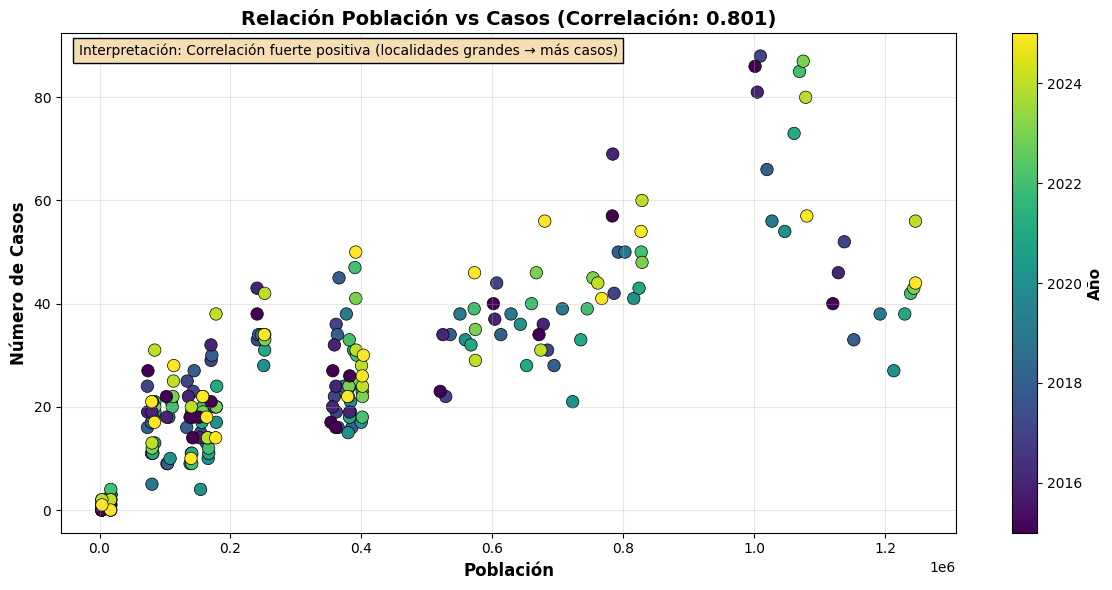

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

# scatter() crea el gráfico de dispersión
# c=df_mortalidad_bgta['Año'] colorea los puntos según el año
# cmap='viridis' es la paleta de colores (azul->verde->amarillo)
# s=80 es el tamaño de los puntos
scatter1 = ax.scatter(df_mortalidad_bgta['Población'], 
                      df_mortalidad_bgta['Casos'], 
                      c=df_mortalidad_bgta['Año'], 
                      cmap='viridis', 
                      s=80, edgecolors='black', linewidth=0.5)

# Configuramos etiquetas y título
ax.set_xlabel('Población', fontsize=12, fontweight='bold')
ax.set_ylabel('Número de Casos', fontsize=12, fontweight='bold')
ax.set_title(f'Relación Población vs Casos (Correlación: {correlacion.loc["Población", "Casos"]:.3f})', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

# Agregamos una barra de colores (colorbar) para interpretar los años
cbar1 = plt.colorbar(scatter1, ax=ax)
cbar1.set_label('Año', fontsize=11, fontweight='bold')

# Interpretación de la correlación
if correlacion.loc["Población", "Casos"] > 0.7:
    interpretation = "fuerte positiva (localidades grandes → más casos)"
elif correlacion.loc["Población", "Casos"] > 0.3:
    interpretation = "moderada positiva (aumentan juntas)"
elif correlacion.loc["Población", "Casos"] > -0.3:
    interpretation = "débil (no hay relación clara)"
else:
    interpretation = "negativa (relación inversa)"

ax.text(0.02, 0.98, f'Interpretación: Correlación {interpretation}', 
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(facecolor='wheat'))

plt.tight_layout()
plt.show()


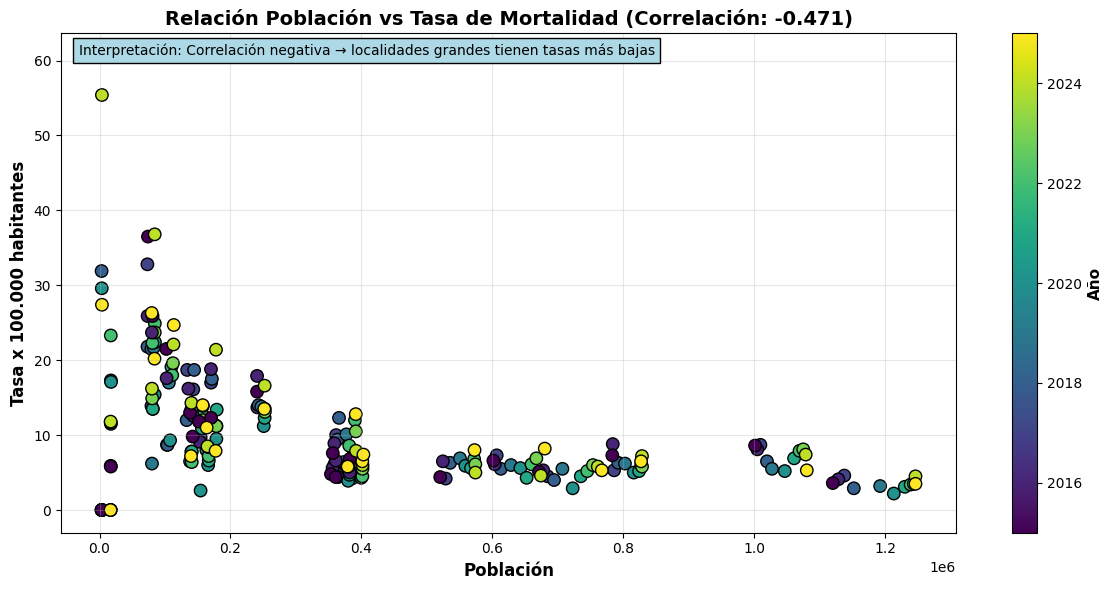

In [71]:
fig, ax = plt.subplots(figsize=(12, 6))

scatter2 = ax.scatter(df_mortalidad_bgta['Población'], 
                      df_mortalidad_bgta['Tasa X 100.000 habitantes'], 
                      c=df_mortalidad_bgta['Año'], cmap='viridis', 
                      s=80, edgecolors='black')

# Configuramos etiquetas y título
ax.set_xlabel('Población', fontsize=12, fontweight='bold')
ax.set_ylabel('Tasa x 100.000 habitantes', fontsize=12, fontweight='bold')
ax.set_title(f'Relación Población vs Tasa de Mortalidad (Correlación: {correlacion.loc["Población", "Tasa X 100.000 habitantes"]:.3f})', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

# Agregamos colorbar para mostrar años
cbar2 = plt.colorbar(scatter2, ax=ax)
cbar2.set_label('Año', fontsize=11, fontweight='bold')

# Interpretación de la correlación entre población y tasa
corr_tasa = correlacion.loc["Población", "Tasa X 100.000 habitantes"]
if abs(corr_tasa) < 0.3:
    interpretation_tasa = "IMPORTANTE: Sin correlación → riesgo es INDEPENDIENTE de la población"
elif corr_tasa > 0.3:
    interpretation_tasa = "Correlación positiva → localidades grandes tienen tasas más altas"
else:
    interpretation_tasa = "Correlación negativa → localidades grandes tienen tasas más bajas"

ax.text(0.02, 0.98, f'Interpretación: {interpretation_tasa}', 
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(facecolor='lightblue'))

plt.tight_layout()
plt.show()


## 5. Estadísticas Descriptivas Generales
Revisemos las estadísticas descriptivas completas de las variables numéricas principales.

In [74]:
estadisticas = df_mortalidad_bgta[['Casos', 'Población', 'Tasa X 100.000 habitantes']].describe()
pd.set_option('display.float_format', '{:.2f}'.format)

print("ESTADÍSTICAS DESCRIPTIVAS GENERALES")
display(estadisticas)

# Información adicional
print("INFORMACIÓN ADICIONAL")
print(f"Total acumulado de casos (2017-2025): {df_mortalidad_bgta['Casos'].sum():.0f}")
print(f"Promedio de casos por año: {df_mortalidad_bgta.groupby('Año')['Casos'].sum().mean():.2f}")

ESTADÍSTICAS DESCRIPTIVAS GENERALES


,Casos,Población,Tasa X 100.000 habitantes
count,220.00,220.00,220.00
mean,27.09,382366.35,10.52
std,17.72,336493.96,8.32
min,0.00,3137.00,0.00
25%,17.00,128191.25,5.57
50%,24.00,303027.50,7.70
75%,36.25,581124.00,13.50
max,88.00,1246637.00,60.60


INFORMACIÓN ADICIONAL
Total acumulado de casos (2017-2025): 5959
Promedio de casos por año: 541.73


## 6. Mapa de Calor: Año vs Localidad
Finalmente, creamos un mapa de calor para visualizar la evolución de la tasa de mortalidad por localidad a lo largo del tiempo.

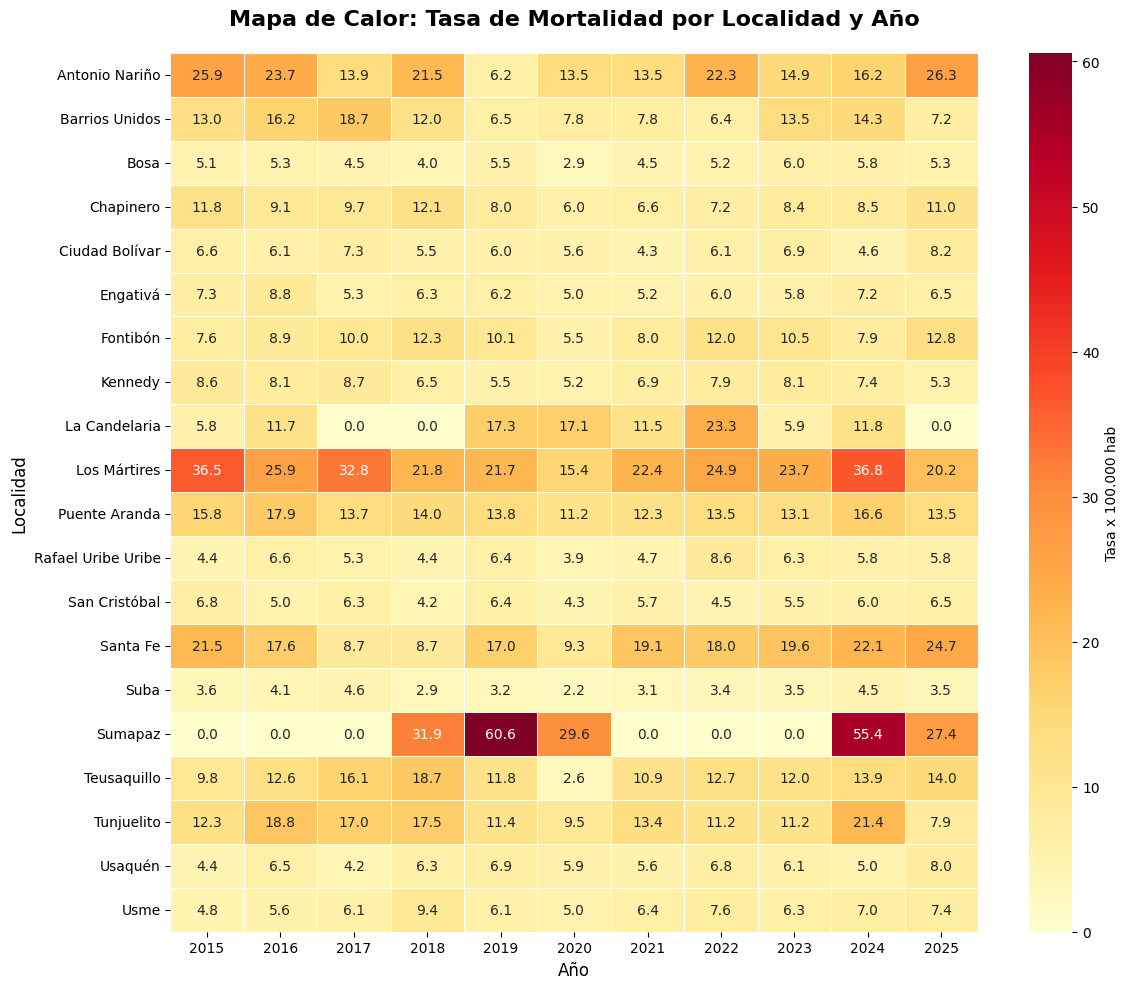

In [20]:
# Creamos una tabla pivote para el mapa de calor
pivot_tasa = df_mortalidad_bgta.pivot_table(
    values='Tasa X 100.000 habitantes',
    index='Localidad',
    columns='Año',
    aggfunc='mean'
)

# Mapa de calor
plt.figure(figsize=(12, 10))
sns.heatmap(pivot_tasa, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5, cbar_kws={'label': 'Tasa x 100.000 hab'})
plt.title('Mapa de Calor: Tasa de Mortalidad por Localidad y Año', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Localidad', fontsize=12)
plt.tight_layout()
plt.show()

### 6.1 Mapa de Calor de Casos
También visualizamos el número de casos para ver patrones en valores absolutos.

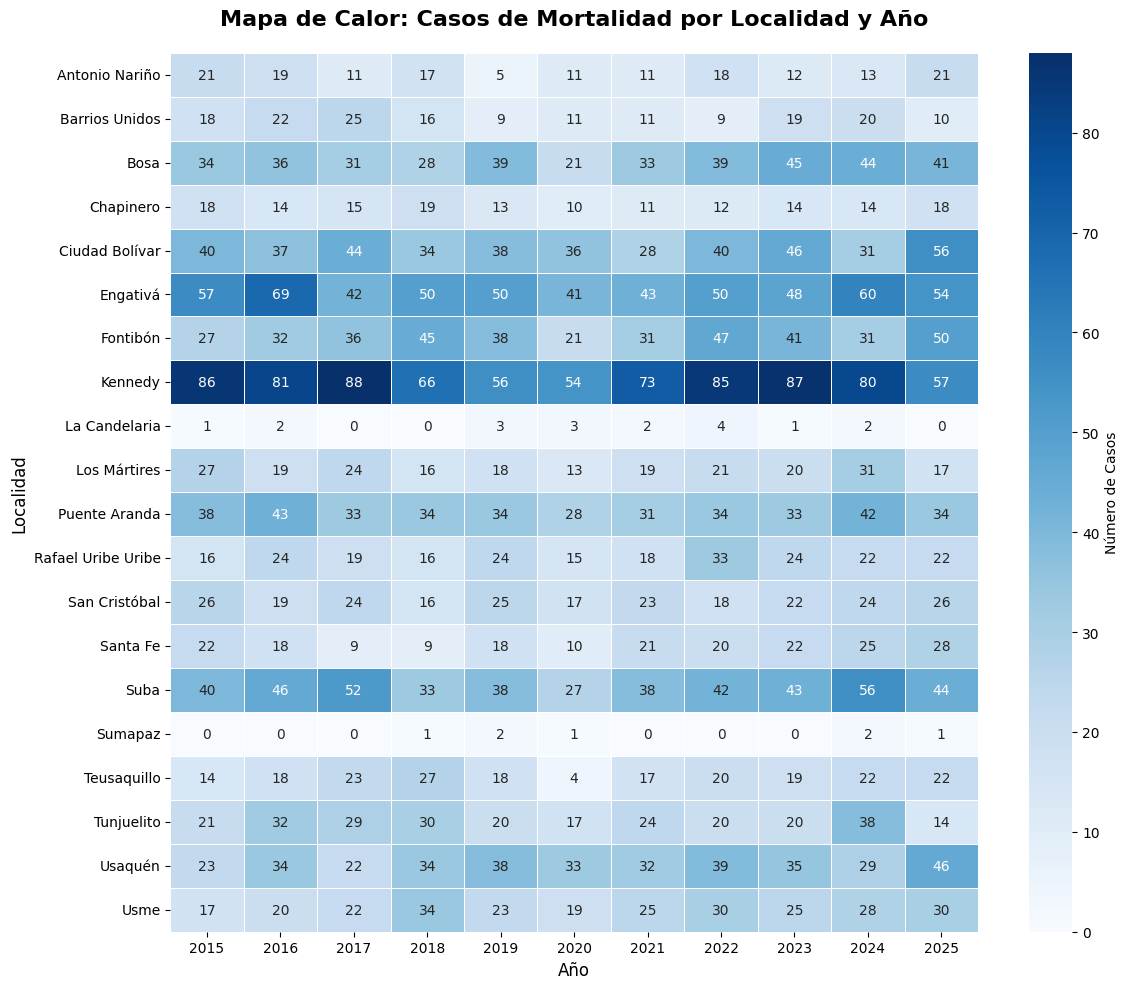

In [21]:
# Mapa de calor para casos
pivot_casos = df_mortalidad_bgta.pivot_table(
    values='Casos',
    index='Localidad',
    columns='Año',
    aggfunc='sum'
)

plt.figure(figsize=(12, 10))
sns.heatmap(pivot_casos, annot=True, fmt='.0f', cmap='Blues', linewidths=0.5, cbar_kws={'label': 'Número de Casos'})
plt.title('Mapa de Calor: Casos de Mortalidad por Localidad y Año', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Localidad', fontsize=12)
plt.tight_layout()
plt.show()